In [ ]:
# Regression Analysis

In [ ]:
### import required packages 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
### load data

In [70]:
from sklearn.datasets import make_regression
# generate data for regression

x, y = make_regression(n_samples = 10000,n_features = 1,n_informative = 1,n_targets=1,noise = 10)

In [71]:
x

array([[ 0.60014243],
       [-1.1252527 ],
       [-0.08538293],
       ...,
       [-0.77015013],
       [-1.02329923],
       [ 1.5958931 ]], shape=(10000, 1))

In [72]:
y

array([ 62.42720942, -91.00613357, -16.40004043, ..., -60.49095066,
       -91.0625017 , 133.79602545], shape=(10000,))

In [73]:
### exploratory data analysis

In [74]:
# convert the array into dataframe
x = pd.DataFrame(x, columns=['feature'])

In [75]:
# get general information
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   feature  10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


In [76]:
# get statstical information
x.describe()

,feature
count,10000.000000
mean,-0.005799
std,1.015907
min,-4.352353
25%,-0.684178
50%,-0.001729
75%,0.684874
max,3.315963


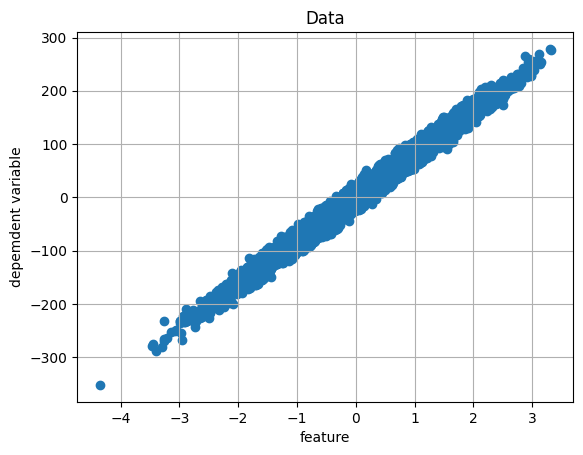

In [77]:
# get the visualization
plt.scatter(x["feature"],y)
plt.xlabel("feature")
plt.ylabel("depemdent variable")
plt.title("Data")
plt.grid()

In [78]:
# correlation analysis

np.corrcoef(x["feature"],y)

array([[1.        , 0.99273399],
       [0.99273399, 1.        ]])

In [79]:
### split the data

In [80]:
from sklearn.model_selection import train_test_split

# split the data into train and test sets randomly
# if length of dataset > 10K = 70:30
# if length of dataset < 10K = 80:20
x_train , x_test, y_train,y_test = train_test_split(x,y,train_size=0.7)

In [81]:
### train the model

In [82]:
from sklearn.linear_model import LinearRegression

# create a model
model = LinearRegression()

# fit the data 
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[81.59]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['feature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.04561
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [83]:
### evaluate the model

In [84]:
# calculate/predict the values for test sets
y_pred = model.predict(x_test)

In [85]:
# calculate mae

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print(f"mean absolute error : {mae:.2f}")

mean absolute error : 7.99


In [86]:
# mean absolute percentage error

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test,y_pred)
print(f"mean absolute percentage error : {mape:.2f}%")

mean absolute percentage error : 0.65%


In [87]:
# mean squared error

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
print(f"mean squared error : {mse:.2f}")

mean squared error : 101.50


In [88]:
# root mean squared error

from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test,y_pred)
print(f"root mean squared error : {rmse:.2f}")

root mean squared error : 10.07


In [89]:
# r2 score

from sklearn.metrics import r2_score
r2s = r2_score(y_test,y_pred)
print(f"r2 score : {r2s:.2f}")

r2 score : 0.99
